# Statystyki datasetu

Ten notebook podsumowuje przygotowany dataset grafów używany w `model_training.ipynb`.
Działa bezpośrednio na pliku `worldcup_2022_graphs.pt`, więc nie wymaga uruchamiania preprocessingu.

In [14]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

## Wczytanie grafów

In [2]:
graphs = torch.load(
    "worldcup_2022_graphs.pt",
    map_location="cpu",
    weights_only=False,
)

print("Liczba grafów:", len(graphs))
print("Pierwszy graf:")
print(graphs[0])

Number of graphs: 165438
First graph:
Data(x=[18, 9], edge_index=[2, 78], edge_attr=[78, 3], actor_mask=[18], event_features=[1, 8], y_pressure=[1], y_turnover=[1], event_id='05a57281-9295-408a-9c4f-e32d7fad4d96', match_id=3857276, event_index=5)


## Budowa tabeli statystyk

Typ zdarzenia jest odtwarzany z `event_features`. Podczas budowy grafów ostatnie cztery cechy zdarzenia są zapisane jako one-hot: `Pass`, `Carry`, `Dribble`, `Ball Receipt*`.

In [3]:
EVENT_TYPE_COLUMNS = ["Pass", "Carry", "Dribble", "Ball Receipt*"]


def get_event_type(graph):
    event_one_hot = graph.event_features.squeeze(0)[4:8].detach().cpu().numpy()
    if event_one_hot.sum() == 0:
        return "Unknown"
    return EVENT_TYPE_COLUMNS[int(event_one_hot.argmax())]


rows = []

for graph in graphs:
    num_nodes = int(graph.x.shape[0])
    num_edges = int(graph.edge_index.shape[1])

    rows.append({
        "id_zdarzenia": graph.event_id,
        "id_meczu": int(graph.match_id),
        "indeks_zdarzenia": int(graph.event_index),
        "typ_zdarzenia": get_event_type(graph),
        "pressure": int(graph.y_pressure.item()),
        "turnover": int(graph.y_turnover.item()),
        "liczba_zawodnikow": num_nodes,
        "liczba_krawedzi": num_edges,
        "sredni_stopien_skierowany": num_edges / num_nodes,
        "sredni_stopien_nieskierowany": (2 * num_edges) / num_nodes,
    })

stats_df = pd.DataFrame(rows)
stats_df.head()

,event_id,match_id,event_index,event_type,pressure,turnover,num_nodes,num_edges,avg_degree_directed,avg_degree_undirected_equiv
0,05a57281-9295-408a-9c4f-e32d7fad4d96,3857276,5,Pass,0,0,18,78,4.333333,8.666667
1,3a06bcce-1408-4a0b-be01-f6b93f142b30,3857276,8,Pass,0,0,20,86,4.300000,8.600000
2,1f1b0ef8-1a1d-45b3-bf9c-4299ea836377,3857276,11,Pass,0,0,17,72,4.235294,8.470588
3,84cdb79d-76e6-408a-bbc4-34026594624a,3857276,14,Pass,0,0,12,52,4.333333,8.666667
4,28e07622-dd23-4af6-8439-cb9856c545db,3857276,17,Pass,0,0,15,64,4.266667,8.533333


## Podstawowe podsumowanie datasetu

In [4]:
summary = pd.DataFrame([
    {"metryka": "liczba grafów", "wartosc": len(stats_df)},
    {"metryka": "liczba meczów", "wartosc": stats_df["id_meczu"].nunique()},
    {"metryka": "średnia liczba zawodników w grafie", "wartosc": stats_df["liczba_zawodnikow"].mean()},
    {"metryka": "średnia liczba krawędzi w grafie", "wartosc": stats_df["liczba_krawedzi"].mean()},
    {"metryka": "średni stopień grafu skierowanego", "wartosc": stats_df["sredni_stopien_skierowany"].mean()},
    {"metryka": "średni stopień w interpretacji nieskierowanej", "wartosc": stats_df["sredni_stopien_nieskierowany"].mean()},
])

summary

,metric,value
0,graphs,165438.000000
1,matches,64.000000
2,avg players per graph,15.131179
3,avg edges per graph,84.617512
4,avg directed degree,5.364204
5,avg undirected-equivalent degree,10.728409


## Podział train / validation / test po meczach

In [5]:
unique_match_ids = np.array(sorted(stats_df["id_meczu"].unique()))

train_matches, temp_matches = train_test_split(
    unique_match_ids,
    test_size=0.30,
    random_state=SEED,
)

val_matches, test_matches = train_test_split(
    temp_matches,
    test_size=0.50,
    random_state=SEED,
)

split_by_match = {
    "train": set(train_matches),
    "validation": set(val_matches),
    "test": set(test_matches),
}


def assign_split(match_id):
    for split_name, match_ids in split_by_match.items():
        if match_id in match_ids:
            return split_name
    return "unknown"


stats_df["zbior"] = stats_df["id_meczu"].apply(assign_split)

split_summary = (
    stats_df.groupby("zbior")
    .agg(
        liczba_meczow=("id_meczu", "nunique"),
        liczba_grafow=("id_zdarzenia", "count"),
        odsetek_pressure=("pressure", "mean"),
        odsetek_turnover=("turnover", "mean"),
    )
    .reindex(["train", "validation", "test"])
)

split_summary

,matches,graphs,pressure_rate,turnover_rate
split,,,,
train,44,111643,0.145508,0.060398
validation,10,25152,0.149809,0.062898
test,10,28643,0.144573,0.061586


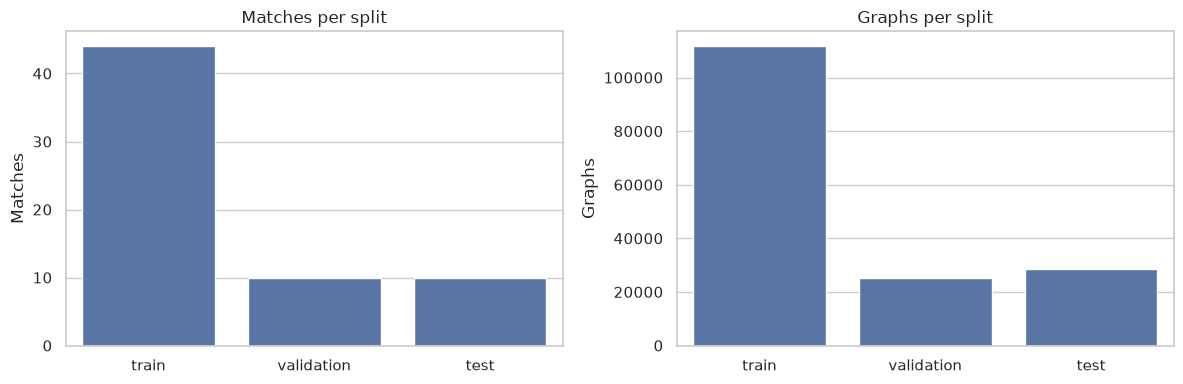

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=split_summary.reset_index(),
    x="zbior",
    y="liczba_meczow",
    ax=axes[0],
)
axes[0].set_title("Liczba meczów w zbiorach")
axes[0].set_xlabel("")
axes[0].set_ylabel("Liczba meczów")

sns.barplot(
    data=split_summary.reset_index(),
    x="zbior",
    y="liczba_grafow",
    ax=axes[1],
)
axes[1].set_title("Liczba grafów w zbiorach")
axes[1].set_xlabel("")
axes[1].set_ylabel("Liczba grafów")

plt.tight_layout()

## Balans klas

In [7]:
class_balance = pd.concat([
    stats_df["pressure"].value_counts().rename_axis("etykieta").reset_index(name="liczba").assign(zadanie="pressure"),
    stats_df["turnover"].value_counts().rename_axis("etykieta").reset_index(name="liczba").assign(zadanie="turnover"),
])

class_balance["odsetek"] = class_balance["liczba"] / class_balance.groupby("zadanie")["liczba"].transform("sum")
class_balance = class_balance.sort_values(["zadanie", "etykieta"])

class_balance

,label,count,task,rate
0,0,141284,pressure,0.854000
1,1,24154,pressure,0.146000
0,0,155349,turnover,0.939016
1,1,10089,turnover,0.060984


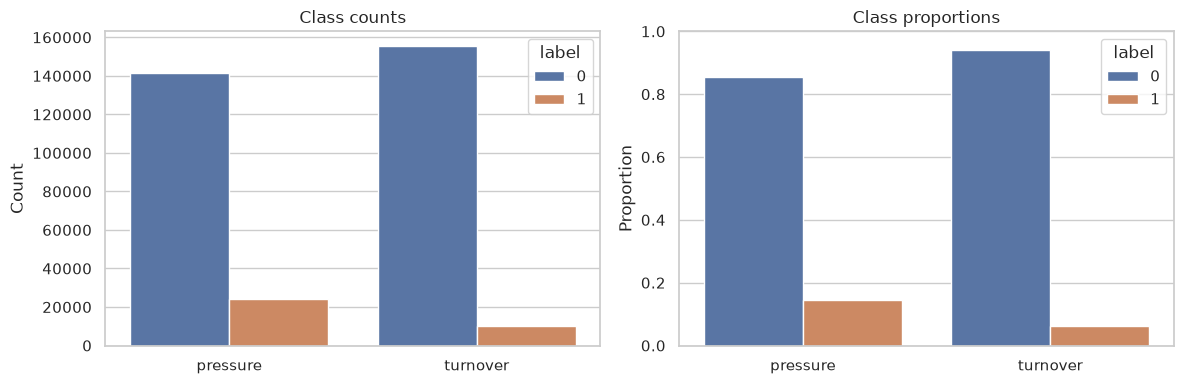

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=class_balance,
    x="zadanie",
    y="liczba",
    hue="etykieta",
    ax=axes[0],
)
axes[0].set_title("Liczebność klas")
axes[0].set_xlabel("")
axes[0].set_ylabel("Liczba grafów")

sns.barplot(
    data=class_balance,
    x="zadanie",
    y="odsetek",
    hue="etykieta",
    ax=axes[1],
)
axes[1].set_title("Proporcje klas")
axes[1].set_xlabel("")
axes[1].set_ylabel("Odsetek")
axes[1].set_ylim(0, 1)

plt.tight_layout()

## Liczba zdarzeń według typu

In [9]:
event_type_counts = (
    stats_df["typ_zdarzenia"]
    .value_counts()
    .reindex(EVENT_TYPE_COLUMNS)
    .rename_axis("typ_zdarzenia")
    .reset_index(name="liczba")
)

event_type_counts["odsetek"] = event_type_counts["liczba"] / event_type_counts["liczba"].sum()
event_type_counts

,event_type,count,rate
0,Pass,57343,0.346613
1,Carry,49403,0.298619
2,Dribble,1477,0.008928
3,Ball Receipt*,57215,0.345840


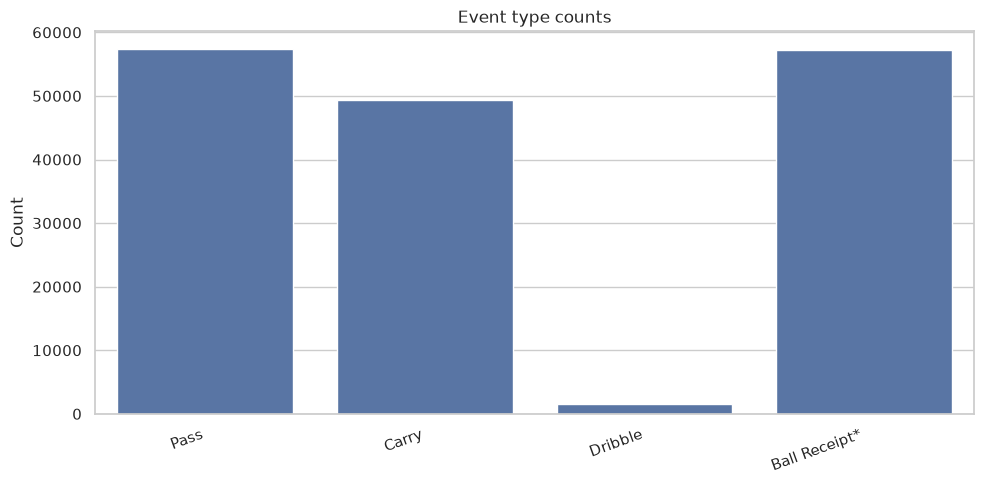

In [10]:
ax = sns.barplot(
    data=event_type_counts,
    x="typ_zdarzenia",
    y="liczba",
)
ax.set_title("Liczba zdarzeń według typu")
ax.set_xlabel("")
ax.set_ylabel("Liczba grafów")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

## Rozkłady rozmiarów grafów

In [11]:
graph_size_summary = stats_df[[
    "liczba_zawodnikow",
    "liczba_krawedzi",
    "sredni_stopien_skierowany",
    "sredni_stopien_nieskierowany",
]].describe().T

graph_size_summary

,count,mean,std,min,25%,50%,75%,max
num_nodes,165438.0,15.131179,3.601534,2.0,13.000000,16.0,18.000000,22.000000
num_edges,165438.0,84.617512,38.905876,2.0,58.000000,84.0,108.000000,392.000000
avg_degree_directed,165438.0,5.364204,1.714463,1.0,4.266667,5.2,6.222222,18.666667
avg_degree_undirected_equiv,165438.0,10.728409,3.428925,2.0,8.533333,10.4,12.444444,37.333333


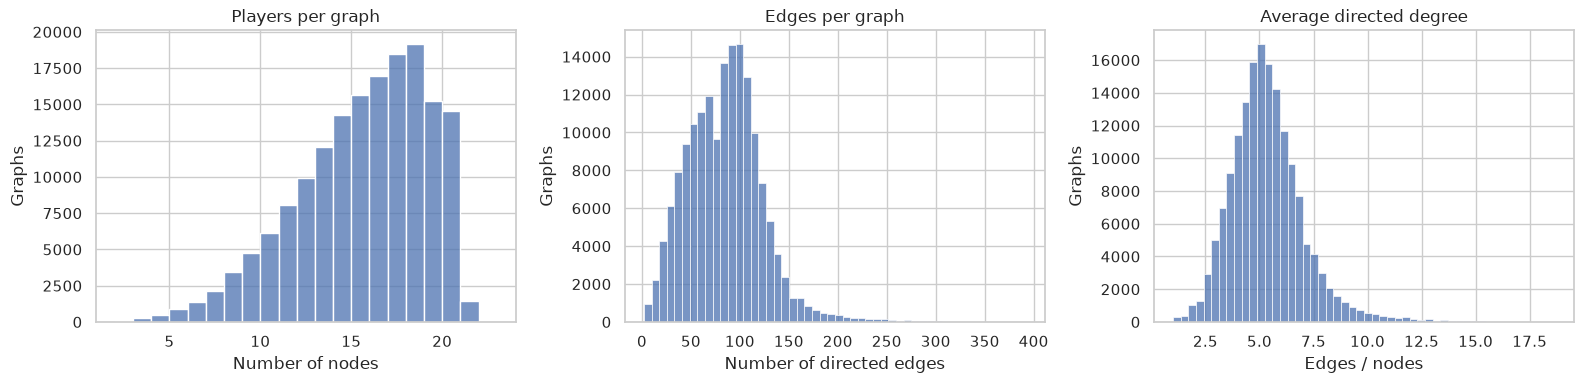

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(stats_df["liczba_zawodnikow"], bins=range(stats_df["liczba_zawodnikow"].min(), stats_df["liczba_zawodnikow"].max() + 2), ax=axes[0])
axes[0].set_title("Liczba zawodników w grafie")
axes[0].set_xlabel("Liczba węzłów")
axes[0].set_ylabel("Liczba grafów")

sns.histplot(stats_df["liczba_krawedzi"], bins=50, ax=axes[1])
axes[1].set_title("Liczba krawędzi w grafie")
axes[1].set_xlabel("Liczba skierowanych krawędzi")
axes[1].set_ylabel("Liczba grafów")

sns.histplot(stats_df["sredni_stopien_skierowany"], bins=50, ax=axes[2])
axes[2].set_title("Średni stopień grafu")
axes[2].set_xlabel("Krawędzie / węzły")
axes[2].set_ylabel("Liczba grafów")

plt.tight_layout()

## Końcowe podsumowanie

In [13]:
final_summary = {
    "liczba grafów": len(stats_df),
    "liczba meczów": stats_df["id_meczu"].nunique(),
    "odsetek pressure=1": stats_df["pressure"].mean(),
    "odsetek turnover=1": stats_df["turnover"].mean(),
    "średnia liczba zawodników w grafie": stats_df["liczba_zawodnikow"].mean(),
    "średnia liczba krawędzi w grafie": stats_df["liczba_krawedzi"].mean(),
    "średni stopień grafu skierowanego": stats_df["sredni_stopien_skierowany"].mean(),
}

pd.Series(final_summary).to_frame("wartosc")

,value
graphs,165438.000000
matches,64.000000
pressure_positive_rate,0.146000
turnover_positive_rate,0.060984
avg_players_per_graph,15.131179
avg_edges_per_graph,84.617512
avg_directed_degree,5.364204


## Najważniejsze obserwacje

- Dataset zawiera **165438 grafów** z **64 meczów**.
- Podział po meczach jest spójny z treningiem: **44 mecze train**, **10 validation**, **10 test**.
- Klasy są mocno niezbalansowane: `pressure=1` występuje w około **14.6%** grafów, a `turnover=1` tylko w około **6.1%** grafów.
- Najczęstsze typy zdarzeń to `Pass` i `Ball Receipt*`, oba po około **34.6%** datasetu. `Carry` stanowi około **29.9%**.
- `Dribble` jest bardzo rzadki: tylko **1477 grafów**, czyli około **0.9%** datasetu.
- Przeciętny graf ma około **15.1 zawodnika**, **84.6 skierowanych krawędzi** i średni stopień skierowany około **5.36**.
- Rozkład splitów jest podobny pod względem udziału klas pozytywnych, więc train/validation/test wyglądają porównywalnie.